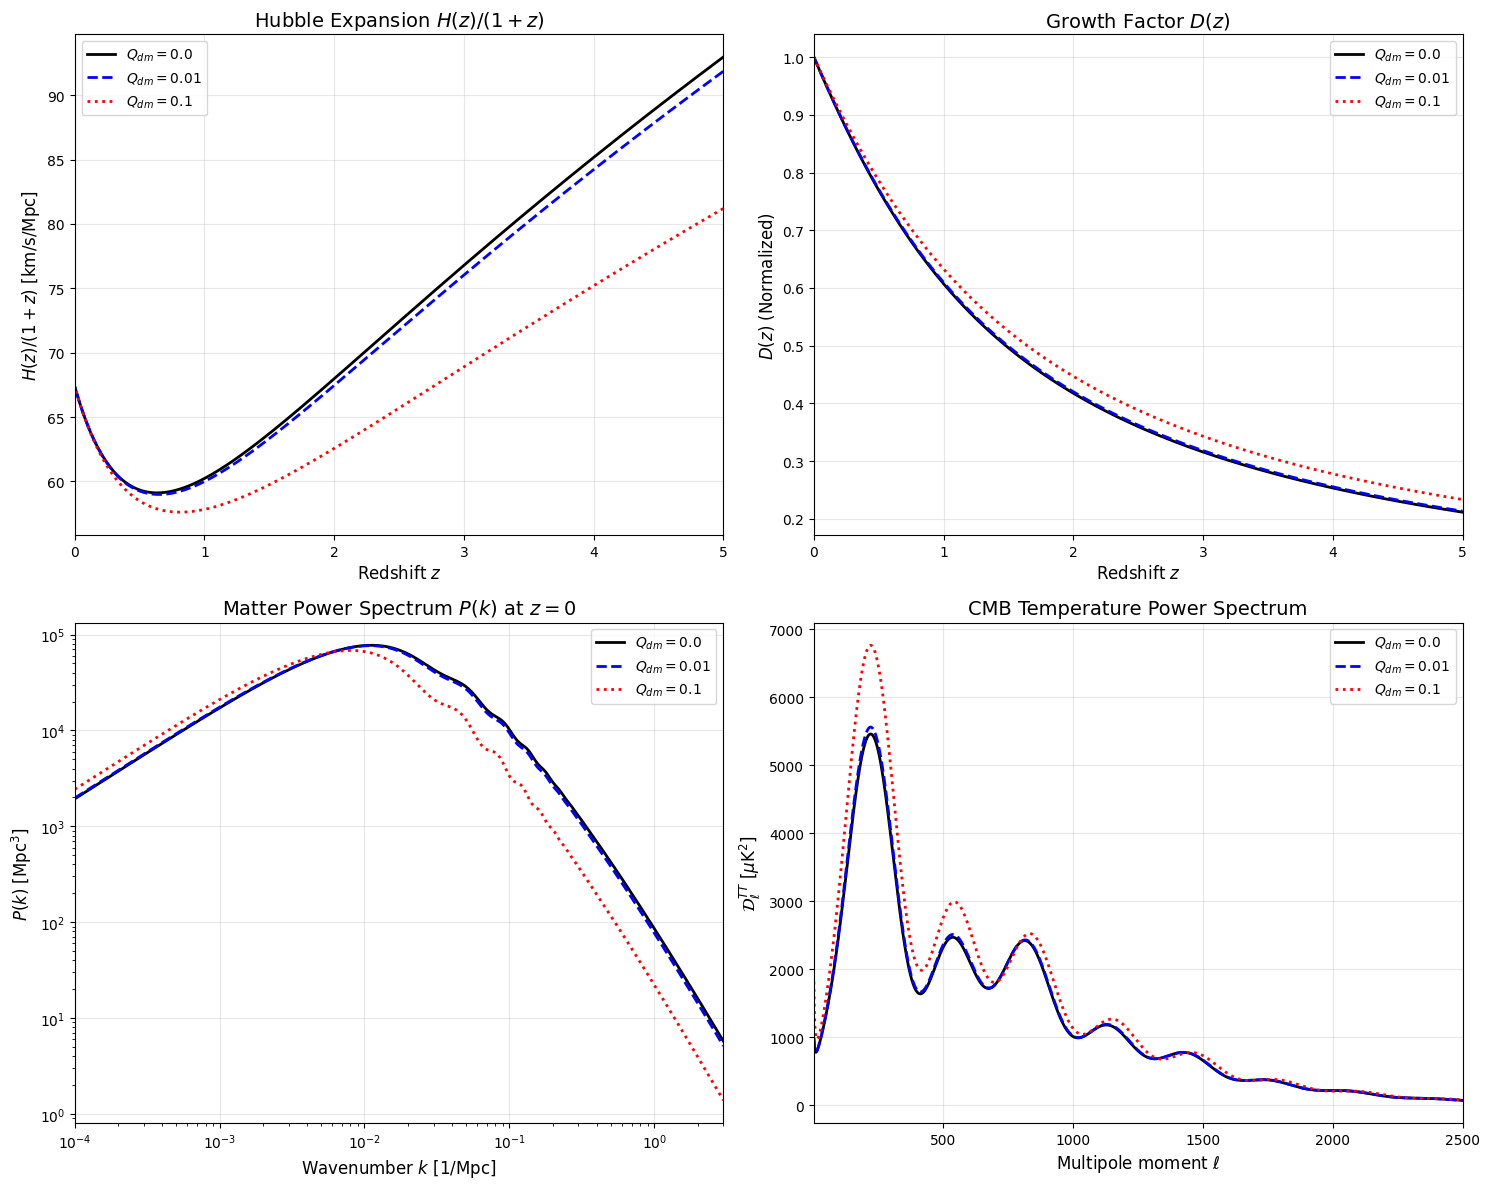

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from classy import Class

# הגדרת ערכי Q_dm שאנחנו רוצים לבדוק (0.0 זה המודל הסטנדרטי LCDM)
Q_dm_values = [0.0, 0.01, 0.1]
colors = ['black', 'blue', 'red']
line_styles = ['-', '--', ':']

# הגדרת חלון הגרפים (2 על 2)
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
plt.subplots_adjust(wspace=0.3, hspace=0.3)

for q, color, ls in zip(Q_dm_values, colors, line_styles):
    
    # אתחול המודל
    cosmo = Class()
    
    # הגדרת הפרמטרים הקוסמולוגיים
# הגדרת הפרמטרים הקוסמולוגיים
    cosmo.set({
        'H0': 67.38,
        'omega_b': 0.02237,
        'omega_cdm': 0.1200,
        'A_s': 2e-9,
        'n_s': 0.965,
        'Q_dm': q,            
        'output': 'tCl, pCl, lCl, mPk', # <--- הוספנו את lCl ואת pCl 
        'lensing': 'yes',     
        'P_k_max_1/Mpc': 3.0, 
        'l_max_scalars': 2500,
        'z_max_pk': 10.0      
    })
    
    # הפעלת מנוע ה-C של CLASS
    cosmo.compute()
    
    # ----------------------------------------------------
    # 1. התפשטות היקום H(z)
    # ----------------------------------------------------
    bg = cosmo.get_background()
    z_array = bg['z']
    
    c_km_s = 299792.458 
    H_z = bg['H [1/Mpc]'] * c_km_s
    
    mask = z_array <= 5.0
    axes[0, 0].plot(z_array[mask], H_z[mask] / (1 + z_array[mask]), 
                    color=color, linestyle=ls, linewidth=2, label=f'$Q_{{dm}} = {q}$')
    
    # ----------------------------------------------------
    # 2. פקטור גידול המבנים D(z) - Growth Factor
    # ----------------------------------------------------
    z_growth = np.linspace(0, 5, 100)
    D_z = np.array([cosmo.scale_independent_growth_factor(z) for z in z_growth])
    
    axes[0, 1].plot(z_growth, D_z, color=color, linestyle=ls, linewidth=2, label=f'$Q_{{dm}} = {q}$')
    
    # ----------------------------------------------------
    # 3. ספקטרום הספק של החומר P(k) ב- z=0
    # ----------------------------------------------------
    k_array = np.logspace(-4, np.log10(3.0), 500)
    pk_array = np.array([cosmo.pk(k, 0.0) for k in k_array])
    
    axes[1, 0].loglog(k_array, pk_array, color=color, linestyle=ls, linewidth=2, label=f'$Q_{{dm}} = {q}$')
    
    # ----------------------------------------------------
    # 4. ספקטרום הספק של ה-CMB (טמפרטורה TT)
    # ----------------------------------------------------
    cls = cosmo.lensed_cl(2500) 
    ell = cls['ell'][2:]
    
    T_cmb_muK = 2.7255 * 1e6
    dl_tt = ell * (ell + 1) * cls['tt'][2:] / (2 * np.pi) * (T_cmb_muK**2)
    
    axes[1, 1].plot(ell, dl_tt, color=color, linestyle=ls, linewidth=2, label=f'$Q_{{dm}} = {q}$')
    
    # חובה לנקות את הזיכרון בסוף הלולאה!
    cosmo.struct_cleanup()
    cosmo.empty()

# ==========================================
# עיצוב הגרפים שייראו מעולה
# ==========================================

# גרף 1
axes[0, 0].set_title('Hubble Expansion $H(z)/(1+z)$', fontsize=14)
axes[0, 0].set_xlabel('Redshift $z$', fontsize=12)
axes[0, 0].set_ylabel('$H(z) / (1+z)$ [km/s/Mpc]', fontsize=12)
axes[0, 0].set_xlim(0, 5)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# גרף 2
axes[0, 1].set_title('Growth Factor $D(z)$', fontsize=14)
axes[0, 1].set_xlabel('Redshift $z$', fontsize=12)
axes[0, 1].set_ylabel('$D(z)$ (Normalized)', fontsize=12)
axes[0, 1].set_xlim(0, 5)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# גרף 3
axes[1, 0].set_title('Matter Power Spectrum $P(k)$ at $z=0$', fontsize=14)
axes[1, 0].set_xlabel('Wavenumber $k$ [1/Mpc]', fontsize=12)
axes[1, 0].set_ylabel('$P(k)$ [Mpc$^3$]', fontsize=12)
axes[1, 0].set_xlim(1e-4, 3)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# גרף 4
axes[1, 1].set_title('CMB Temperature Power Spectrum', fontsize=14)
axes[1, 1].set_xlabel('Multipole moment $\ell$', fontsize=12)
axes[1, 1].set_ylabel('$\mathcal{D}_\ell^{TT}$ [$\mu$K$^2$]', fontsize=12)
axes[1, 1].set_xlim(2, 2500)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()